In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv('/content/Automobile_data.csv')

In [12]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [15]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [16]:
df['normalized-losses'].replace('?',np.nan,inplace=True)
df['bore'].replace('?',np.nan,inplace=True)
df['stroke'].replace('?',np.nan,inplace=True)
df['horsepower'].replace('?',np.nan,inplace=True)
df['peak-rpm'].replace('?',np.nan,inplace=True)
df['price'].replace('?',np.nan,inplace=True)

In [17]:
df.isnull().sum()

,0
symboling,0
normalized-losses,41
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


In [18]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(missing_values=np.nan,strategy='mean')
df[['normalized-losses','bore','stroke','horsepower','peak-rpm','price']] = si.fit_transform(df[['normalized-losses','bore','stroke','horsepower','peak-rpm','price']])

In [19]:
df['num-of-doors'] = df['num-of-doors'].replace('?','four')

In [20]:
features = df.iloc[:,:-1]
target = df.iloc[:,-1]

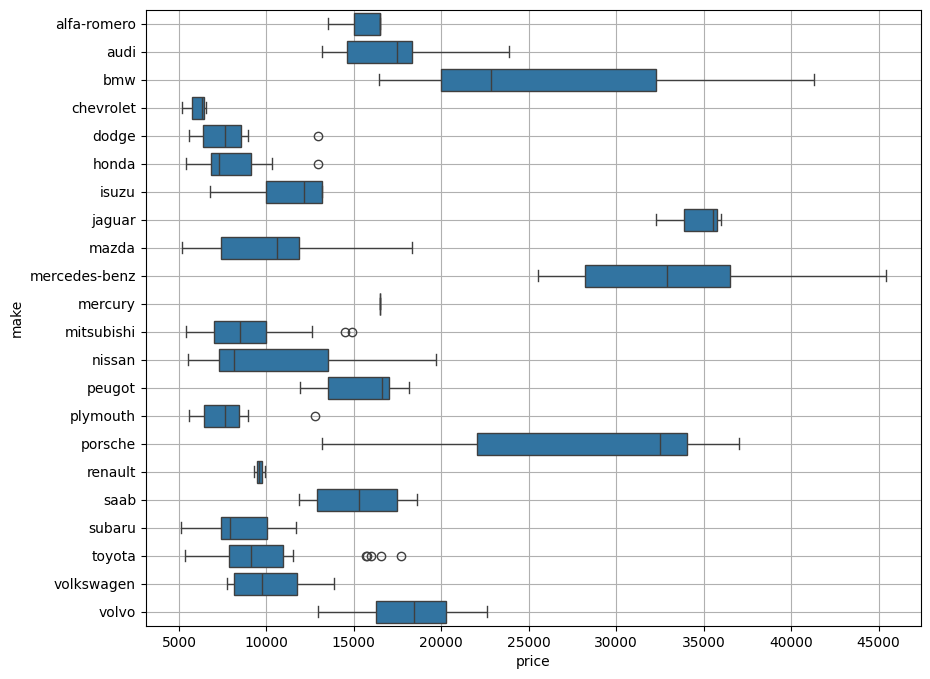

In [21]:
plt.figure(figsize=(10,8))
sns.boxplot(data=features,x=target,y='make')
plt.grid()

In [22]:
i = features[(features.make == 'dodge')&(target>10000)].index
features.drop(i,axis=0,inplace=True)
target.drop(i,axis=0,inplace=True)

i = features[(features.make == 'honda')&(target>12000)].index
features.drop(i,axis = 0,inplace = True)
target.drop(i,axis = 0,inplace = True)

i = features[(features.make == 'mitsubishi')&(target>12500)].index
features.drop(i,axis = 0,inplace = True)
target.drop(i,axis = 0,inplace = True)

i = features[(features.make == 'plymouth')&(target>10000)].index
features.drop(i,axis = 0,inplace = True)
target.drop(i,axis = 0,inplace = True)

i = features[(features.make == 'toyota')&(target>15000)].index
features.drop(i,axis = 0,inplace = True)
target.drop(i,axis = 0,inplace = True)

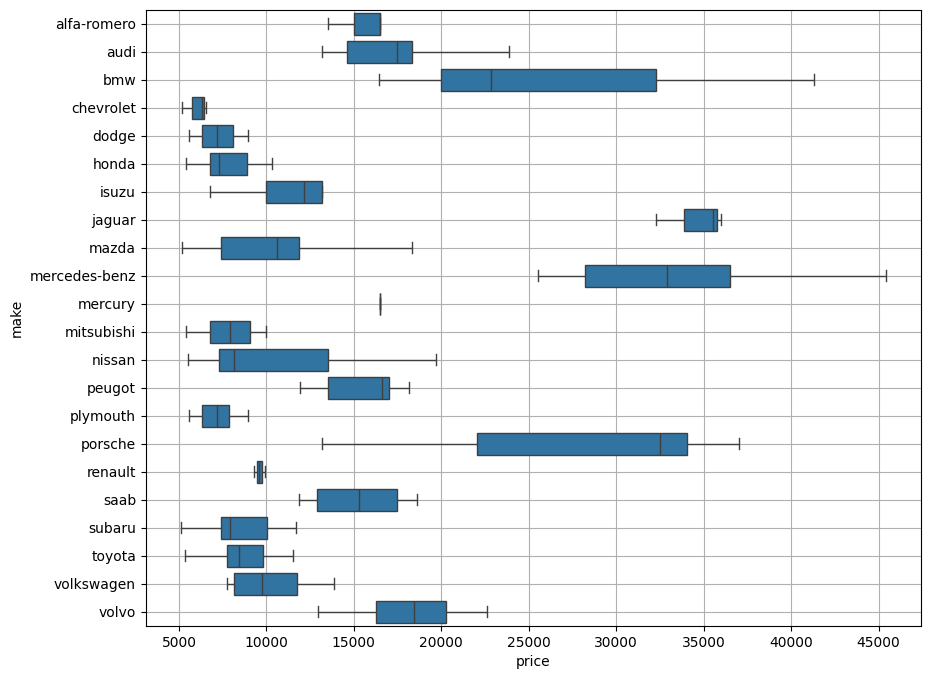

In [23]:
plt.figure(figsize=(10,8))
sns.boxplot(data=features,x=target,y='make')
plt.grid()

In [26]:
colnames = features.select_dtypes(['int64','float64']).columns
colnames

Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg'],
      dtype='object')

symboling
0.22326592087047767
normalized-losses
0.848205953606264
wheel-base
1.0434318954680746
length
0.19318313729179817
width
0.9197264769767646
height
0.017443445468877522
curb-weight
0.7785529269563564
engine-size
2.0704133174547303
bore
0.06006761573130289
stroke
-0.8072553195768107
compression-ratio
2.520677620258808
horsepower
1.5819241758278482
peak-rpm
0.061377963186987905
city-mpg
0.5838226949584431
highway-mpg
0.45878800653395957


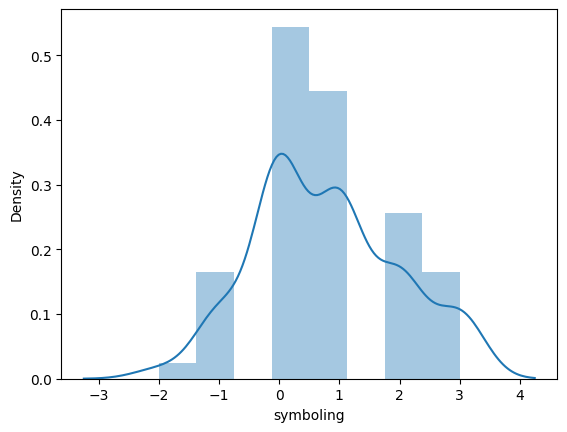

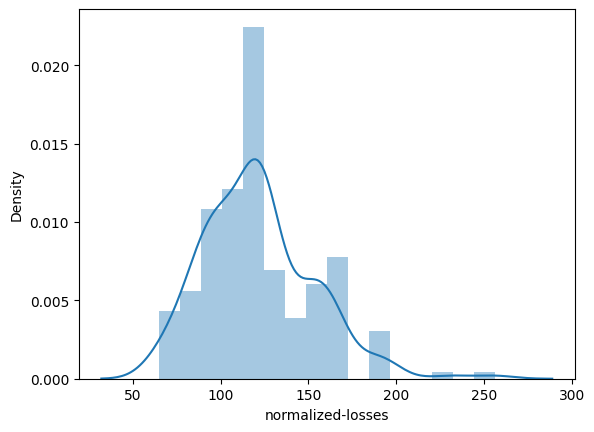

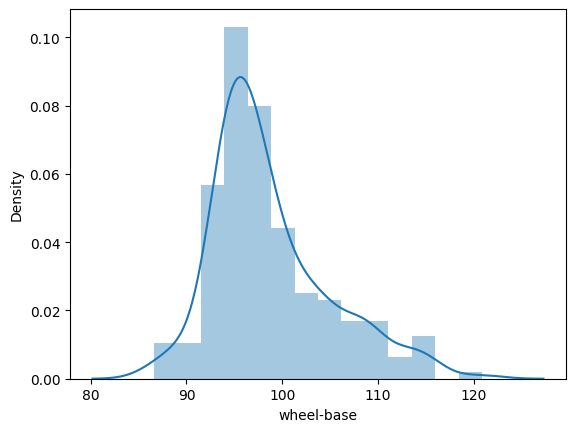

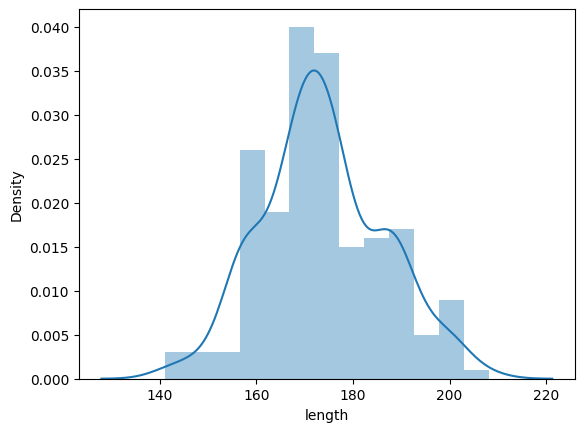

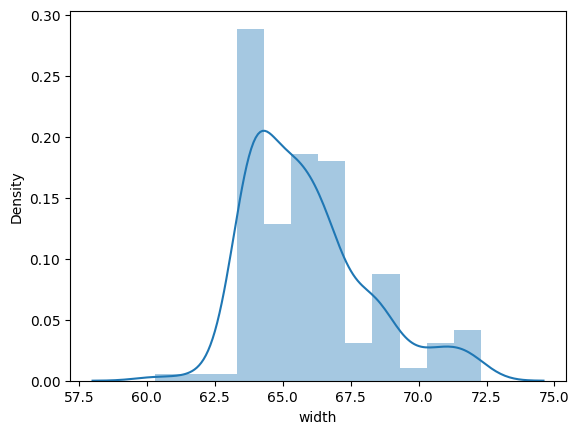

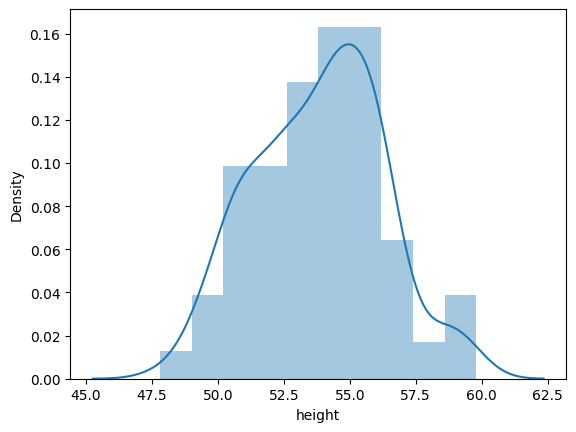

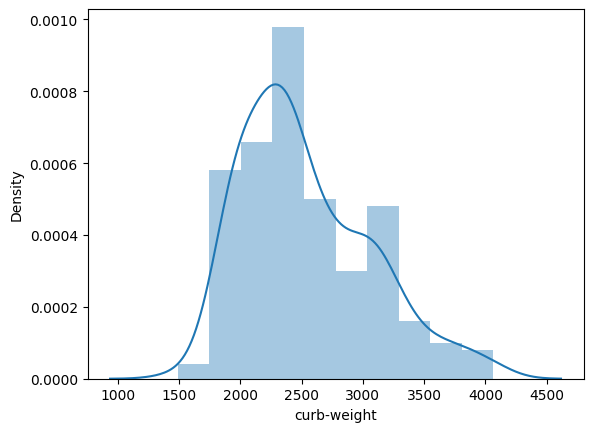

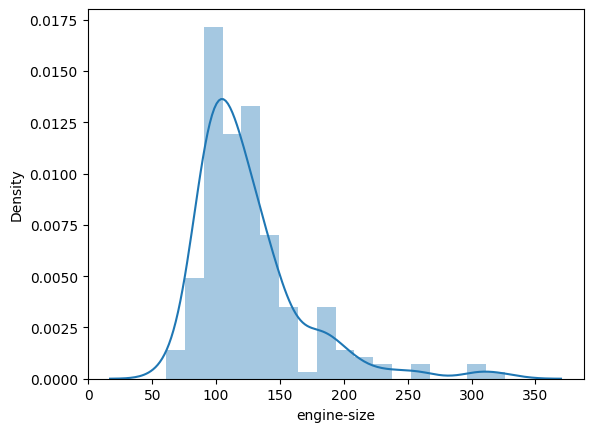

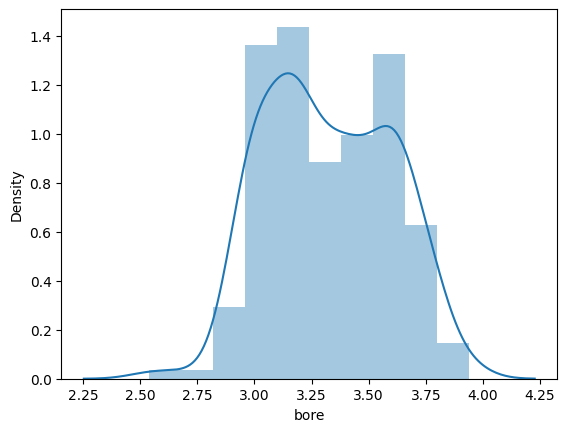

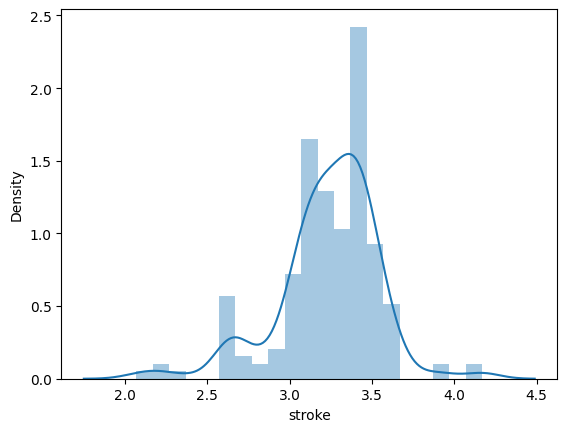

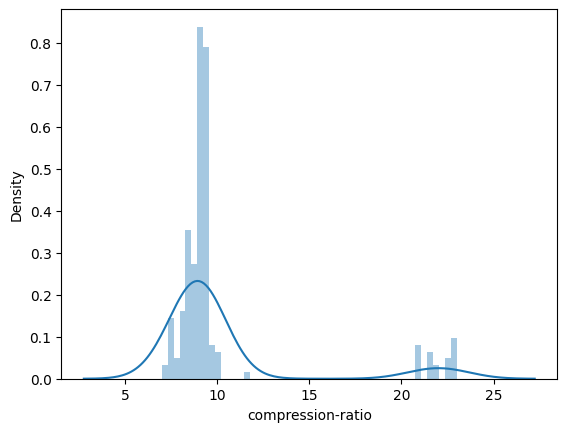

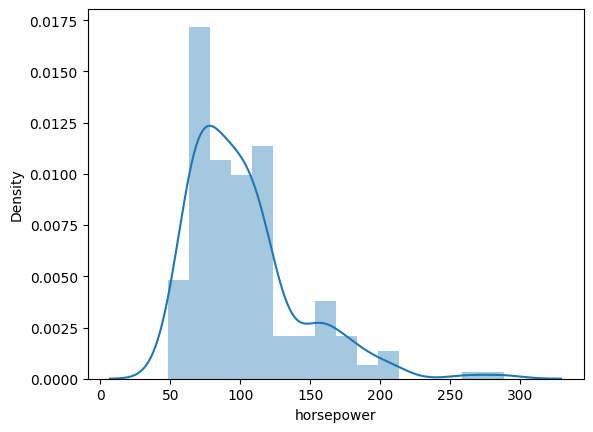

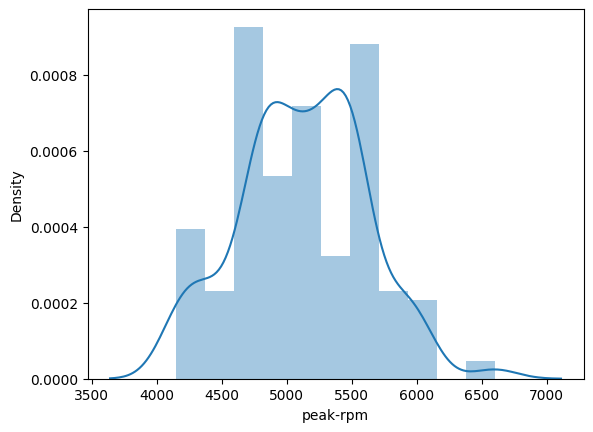

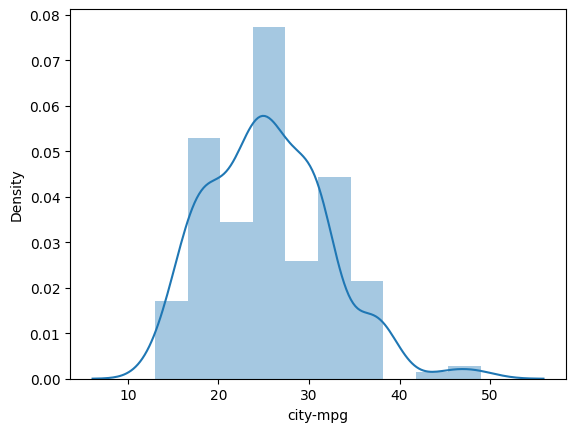

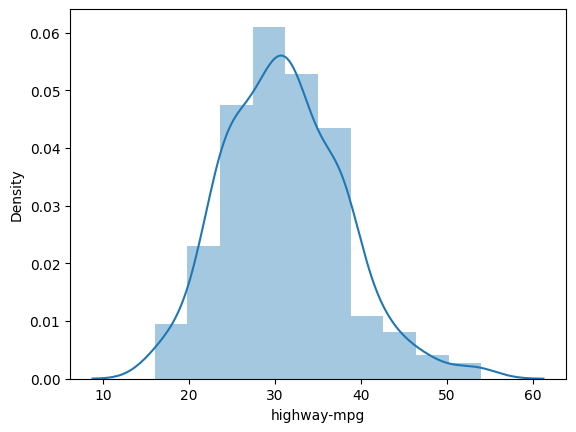

In [28]:
from scipy.stats import skew
for cols in features[colnames]:
    print(cols)
    print(skew(features[cols]))

    plt.figure()
    sns.distplot(features[cols])
    plt.show

In [51]:
pd.concat([features,target],axis=1).corr()['price'].sort_values()

,price
highway-mpg,-0.740975
city-mpg,-0.717768
make,-0.176597
fuel-type,-0.114502
peak-rpm,-0.100492
symboling,-0.096168
body-style,-0.066409
num-of-doors,-0.050143
num-of-cylinders,-0.002013
compression-ratio,0.075046


In [31]:
from scipy import stats

features['highway-mpg'] = np.cbrt(features['highway-mpg'])
print(skew(features['highway-mpg']))

features['city-mpg'] = np.cbrt(features['city-mpg'])
print(skew(features['city-mpg']))

features[' wheel-base'] = np.cbrt(features['wheel-base'])
print(skew(features['wheel-base']))

features['width'] = np.cbrt(features['width'])
print(skew(features['width']))

features['horsepower'] = np.cbrt(features['horsepower'])
print(skew(features['horsepower']))

features['curb-weight'] = np.cbrt(features['curb-weight'])
print(skew(features['curb-weight']))

features['engine-size'] = np.cbrt(features['engine-size'])
print(skew(features['engine-size']))

0.003782440230506038
0.12004656888819494
1.0434318954680746
0.8630336796803285
0.8889013019724904
0.5048593222593741
1.322843067231212


<Axes: ylabel='count'>

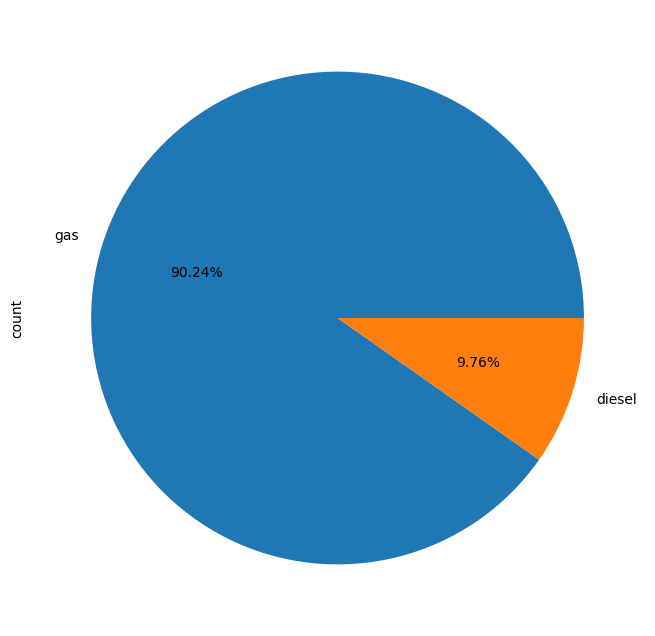

In [32]:
df['fuel-type'].value_counts().plot(figsize=(8,8),kind='pie',autopct='%.2f%%')

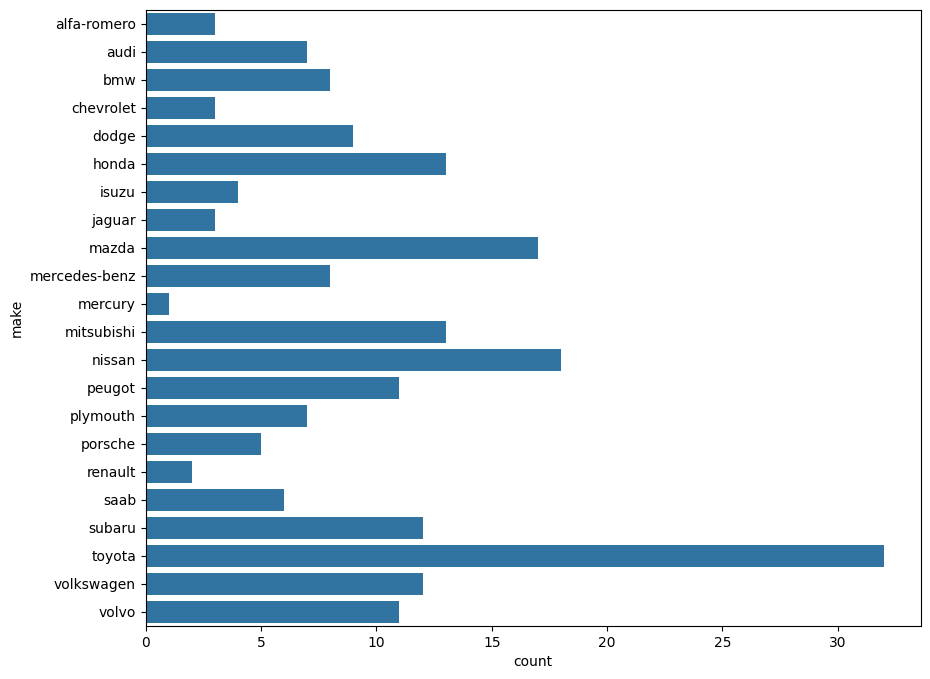

In [35]:
plt.figure(figsize=(10,8))
sns.countplot(data=df,y='make')
plt.show()

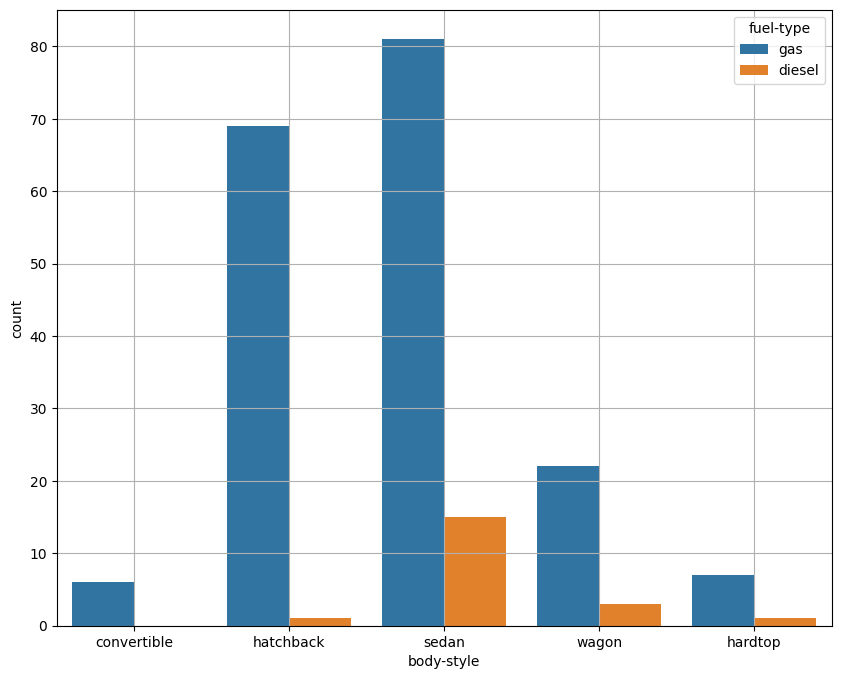

In [36]:
plt.figure(figsize=(10,8))
sns.countplot(data=df,x='body-style',hue='fuel-type')
plt.grid(True)

<function matplotlib.pyplot.show(close=None, block=None)>

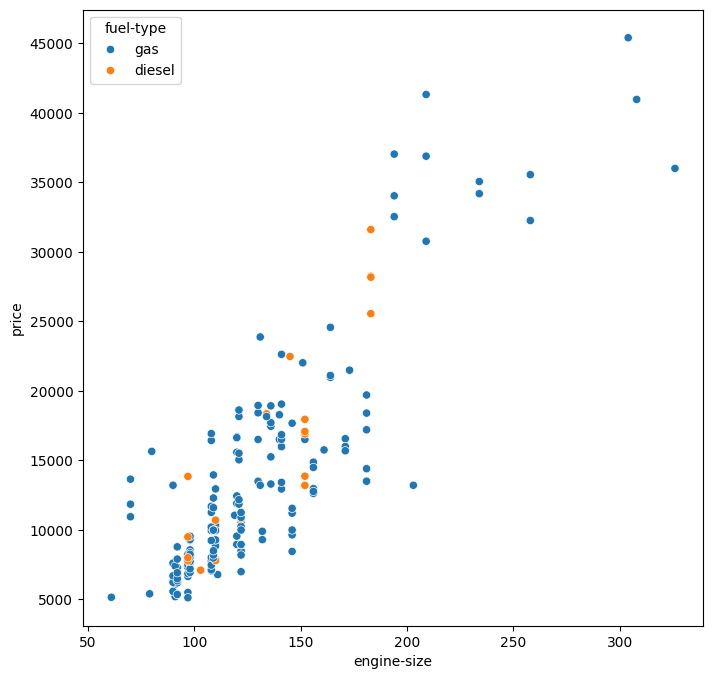

In [62]:
plt.figure(figsize=(8,8))
sns.scatterplot(y='price',x='engine-size',data=df,hue='fuel-type')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

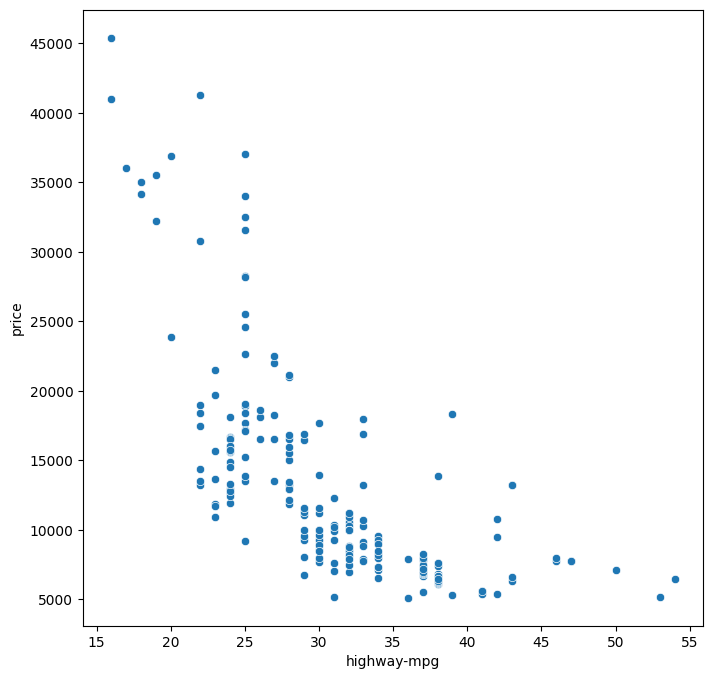

In [63]:
plt.figure(figsize=(8,8))
sns.scatterplot(data=df,x='highway-mpg',y='price')
plt.show

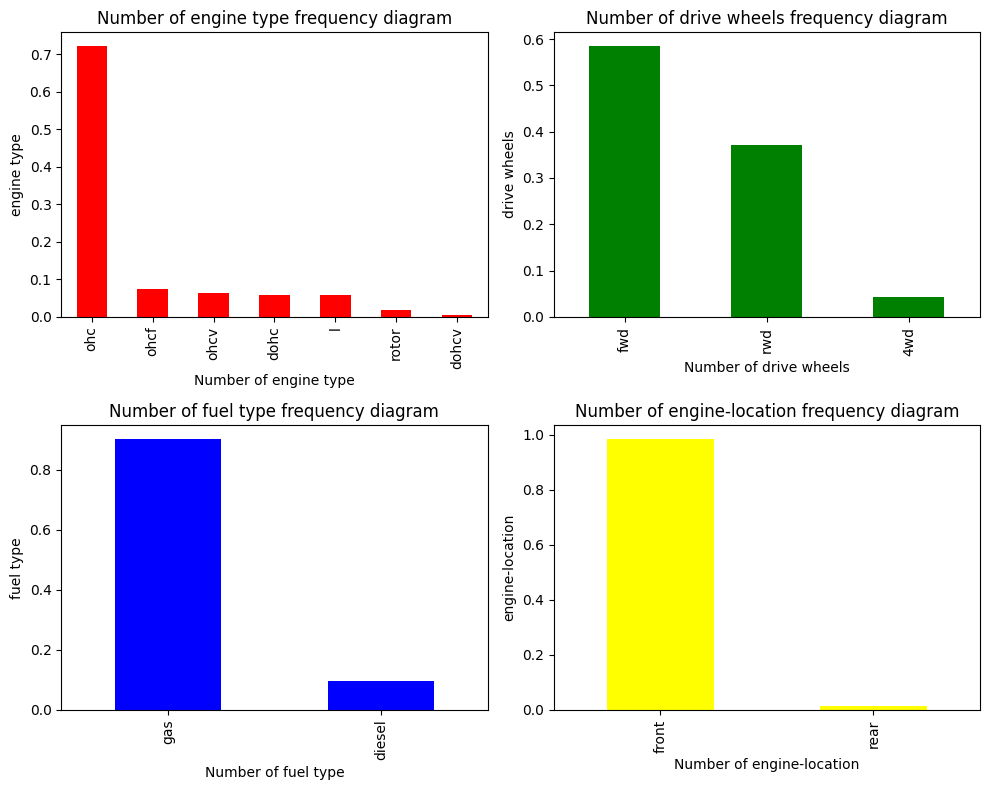

In [64]:
plt.figure(1)
plt.subplot(2,2,1)
df['engine-type'].value_counts(normalize=True).plot(figsize=(10,8),kind='bar',color='red')
plt.title('Number of engine type frequency diagram')
plt.xlabel('Number of engine type')
plt.ylabel('engine type')

plt.subplot(2,2,2)
df['drive-wheels'].value_counts(normalize=True).plot(figsize=(10,8),kind='bar',color='green')
plt.title('Number of drive wheels frequency diagram')
plt.xlabel('Number of drive wheels')
plt.ylabel('drive wheels')

plt.subplot(2,2,3)
df['fuel-type'].value_counts(normalize=True).plot(figsize=(10,8),kind='bar',color='blue')
plt.title('Number of fuel type frequency diagram')
plt.xlabel('Number of fuel type')
plt.ylabel('fuel type')

plt.subplot(2,2,4)
df['engine-location'].value_counts(normalize=True).plot(figsize=(10,8),kind='bar',color='yellow')
plt.title('Number of engine-location frequency diagram')
plt.xlabel('Number of engine-location')
plt.ylabel('engine-location')

plt.tight_layout()

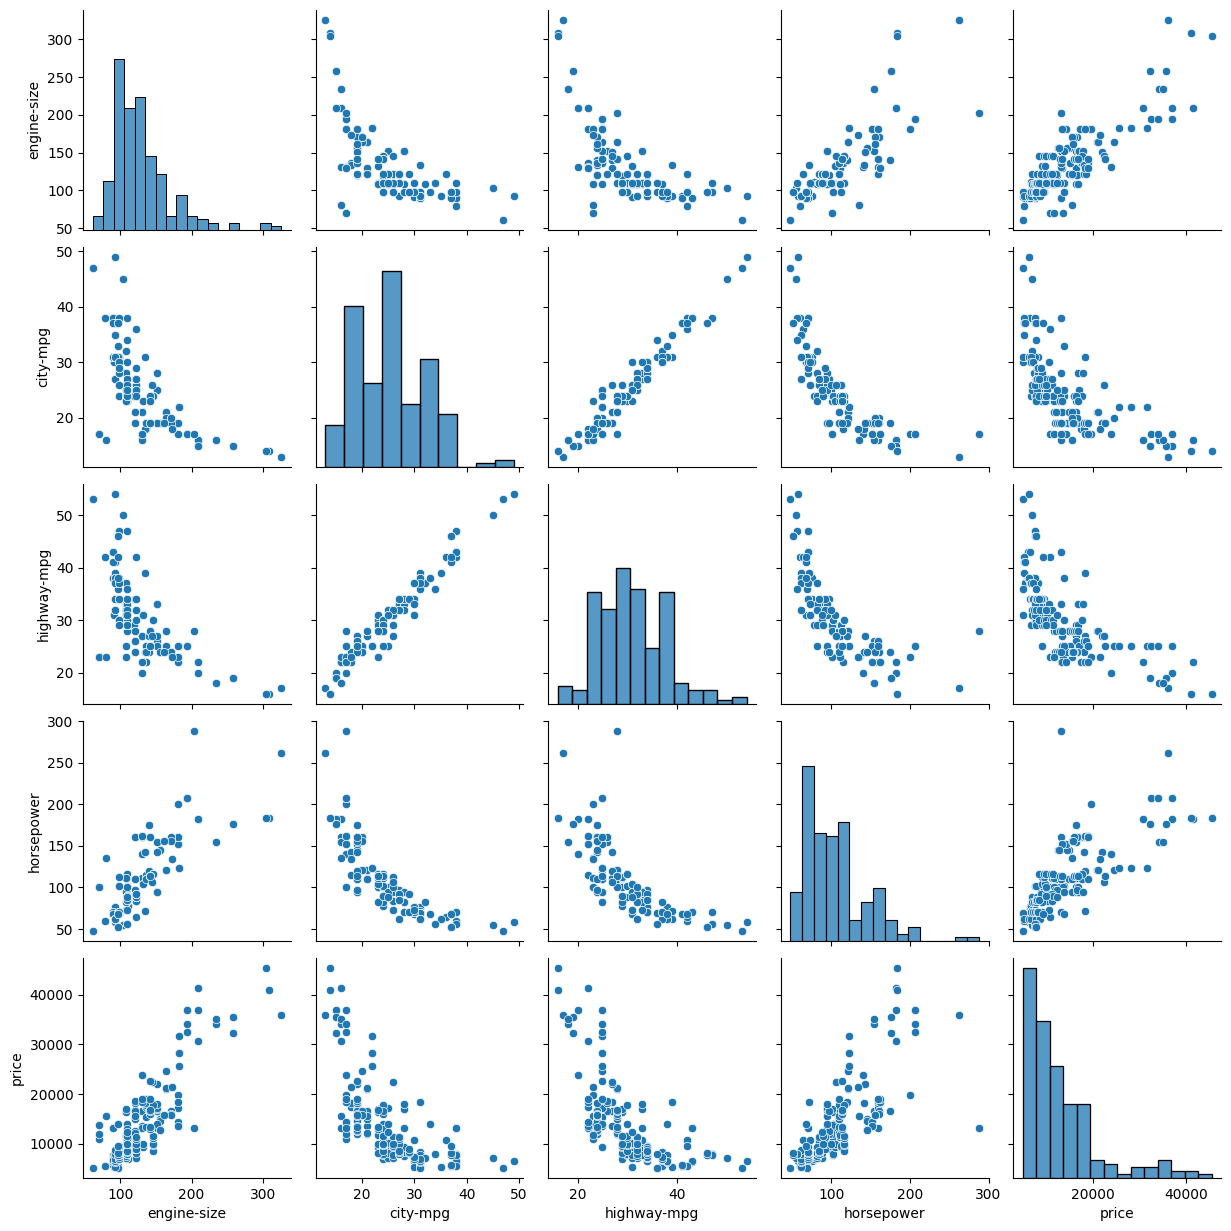

In [65]:
sns.pairplot(df[['engine-size','body-style','city-mpg','highway-mpg','horsepower','price']])

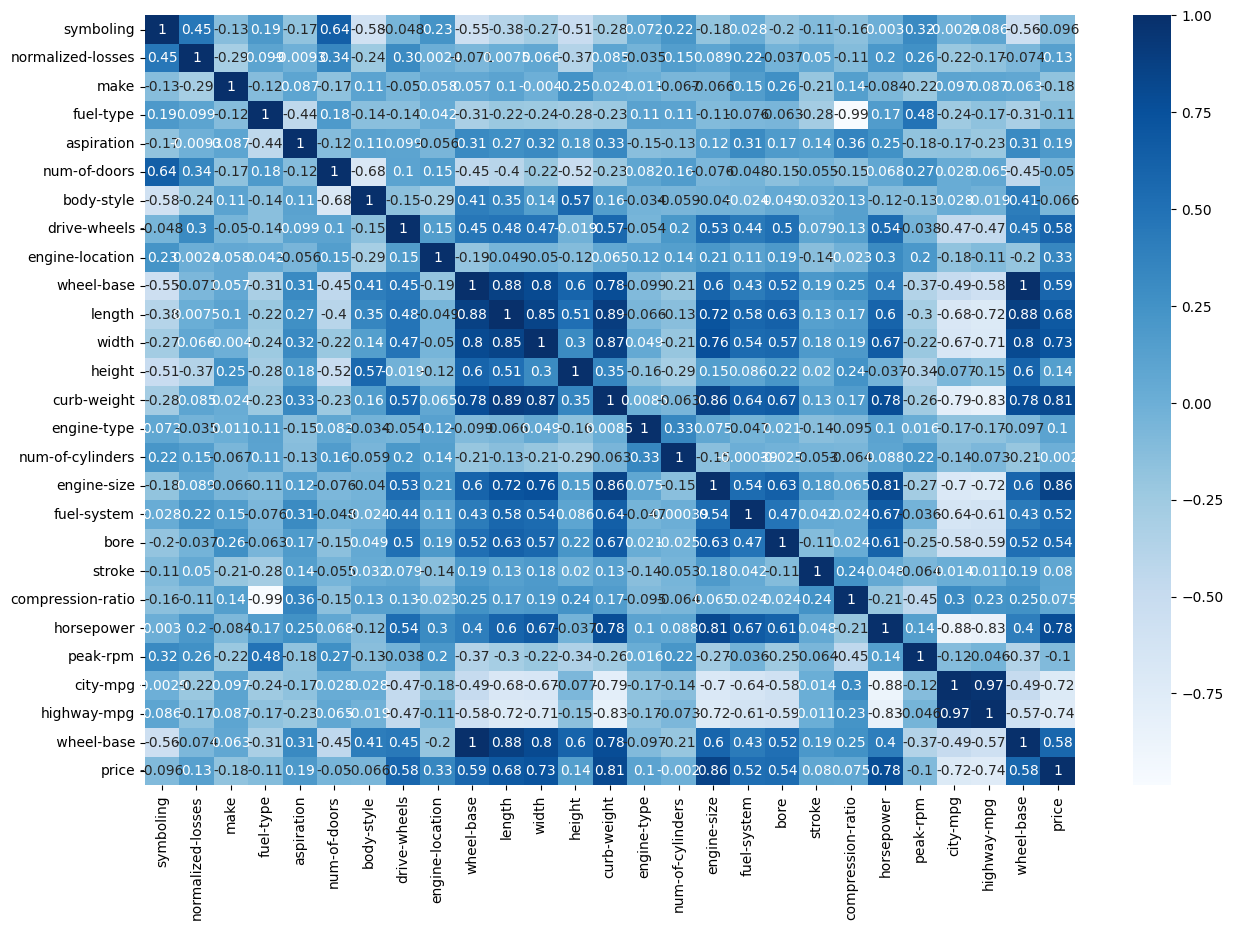

In [67]:
plt.figure(figsize=(15,10))
sns.heatmap(pd.concat([features, target], axis=1).corr(), annot=True, cmap='Blues')
plt.show()

In [68]:
cols = features.select_dtypes(['object']).columns
cols

Index([], dtype='object')

In [69]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
features[cols] = oe.fit_transform(features[cols])
features.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,wheel-base
0,3,122.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,88.6,...,5.065797,4.0,3.47,2.68,9.0,4.805896,5000.0,2.758924,3.000000,4.458046
1,3,122.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,88.6,...,5.065797,4.0,3.47,2.68,9.0,4.805896,5000.0,2.758924,3.000000,4.458046
2,1,122.0,0.0,1.0,0.0,1.0,2.0,2.0,0.0,94.5,...,5.336803,4.0,2.68,3.47,9.0,5.360108,5000.0,2.668402,2.962496,4.554883
3,2,164.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,99.8,...,4.776856,4.0,3.19,3.40,10.0,4.672329,5500.0,2.884499,3.107233,4.638492
4,2,164.0,1.0,1.0,0.0,0.0,3.0,0.0,0.0,99.4,...,5.142563,4.0,3.19,3.40,8.0,4.862944,5500.0,2.620741,2.802039,4.632287


In [70]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(features,target,random_state=2,test_size=0.2)

In [71]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(xtrain,ytrain)
ypred = lr.predict(xtest)

In [72]:
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(ytest,ypred)
r2 = r2_score(ytest,ypred)
print('mean_squared_error : ',mse)
print('r2_score : ',r2)

mean_squared_error :  18179265.100488544
r2_score :  0.6678136852335932


In [73]:
train = lr.score(xtrain,ytrain)
test = lr.score(xtest,ytest)
print(f'Training_Accuracy : {train}\nTesting_Accuracy : {test}')

Training_Accuracy : 0.8776297293657729
Testing_Accuracy : 0.6678136852335932


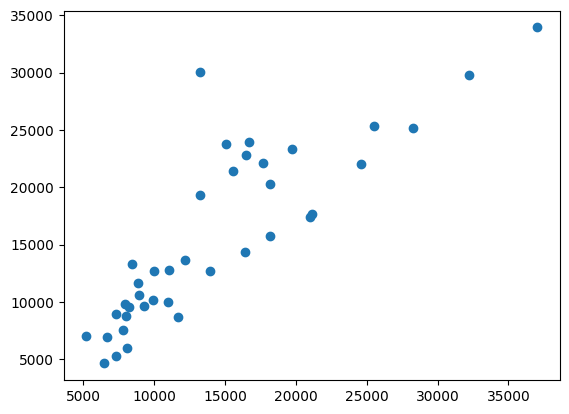

In [74]:
plt.scatter(ytest,ypred)
plt.show()